Q1.
import numpy as np
A = np.array([ [12, 5, 8, 20], [ 7, 15, 3, 11], [25, 9, 18, 6], [10, 14, 2, 16] ])
Perform the following without using explicit Python for loops:
1. Calculate the mean of each row.
2. Replace every element that is greater than its row mean by 1.
3. Replace every other element by 0.
4. Return the resulting binary matrix.
5. Also determine which row contains the maximum number of elements
above its row mean

In [ ]:
import numpy as np
A = np.array([ [12, 5, 8, 20], [ 7, 15, 3, 11], [25, 9, 18, 6], [10, 14, 2, 16] ])
print(A)
#1
row_mean=A.mean(axis=1)
print(row_mean)
#2 and 3
binary= (A > row_mean[:,np.newaxis]).astype(int)
#4
print(binary)
#5
counts = binary.sum(axis=1)

print("\nNo. of elements above row mean:")
print(counts)

print("\nMax no. of elements above row mean:")
print(counts.max())

[[12  5  8 20]
 [ 7 15  3 11]
 [25  9 18  6]
 [10 14  2 16]]
[11.25  9.   14.5  10.5 ]
[[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]

No. of elements above row mean:
[2 2 2 2]

Max no. of elements above row mean:
2


Q2.
X = np.array([ [10, 100, 5], [12, 110, 6], [11, 105, 7], [13, 500, 6], [14, 108, 8], [15,
115, 9] ])
For each column:
1. Calculate the mean and standard deviation.
2. Identify values satisfying:
∣x−μ∣>2σ
3. Replace such values with the corresponding column median.
4. Do this without modifying non-outlier values.

In [ ]:
X = np.array([ [10, 100, 5], [12, 110, 6], [11, 105, 7], [13, 500, 6], [14, 108, 8], [15, 115, 9] ])
#1
mean = X.mean(axis=0)
std = X.std(axis=0)
print(mean)
print(std)

print("")

#2
values_satisfying = np.abs(X - mean) > 2 * std
print("Values Satisfying:")
print(values_satisfying)

#3
median = np.median(X, axis=0)
X[values_satisfying] = median[np.where(values_satisfying)[1]]

print("")
print(X)

[ 12.5        173.           6.83333333]
[  1.70782513 146.31017281   1.34370962]

Values Satisfying:
[[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]

[[ 10 100   5]
 [ 12 110   6]
 [ 11 105   7]
 [ 13 109   6]
 [ 14 108   8]
 [ 15 115   9]]


Q3.
import pandas as pd
df = pd.DataFrame({ 'Student': ['A','B','C','D','E','F','G','H'],
'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
'Gender': ['F','M','F','M','M','F','F','M'],
'Marks': [85,72,91,65,78,88,95,70],
'Attendance': [92,81,96,72,85,90,98,75] })
Find:
1. Average marks for each department.
2. Average marks separately for each (Department, Gender) group.
3. Student with the highest marks in each department.
4. Students whose marks are above their department average.
5. Department having the highest average attendance.

In [ ]:
import pandas as pd
df = pd.DataFrame({ 'Student': ['A','B','C','D','E','F','G','H'],
'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
'Gender': ['F','M','F','M','M','F','F','M'],
'Marks': [85,72,91,65,78,88,95,70],
'Attendance': [92,81,96,72,85,90,98,75] })

#1
avg_marks = df.groupby('Department')['Marks'].mean()
print("1)Average marks by department:")
print(avg_marks)

#2
avg_group = df.groupby(['Department', 'Gender'])['Marks'].mean()
print("\n2)Average marks by department and gender:")
print(avg_group)

#3
highest = df.loc[df.groupby('Department')['Marks'].idxmax()]
print("\n3)Student with highest marks in each department:")
print(highest[['Department', 'Student', 'Marks']])

#4
dept_avg = df.groupby('Department')['Marks'].transform('mean')
above_avg = df[df['Marks'] > dept_avg]
print("\n4)Students above their department average:")
print(above_avg[['Student', 'Department', 'Marks']])

#5
attendance = df.groupby('Department')['Attendance'].mean()
print("\n5. Department with highest average attendance:")
print(attendance.idxmax())


1)Average marks by department:
Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64

2)Average marks by department and gender:
Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64

3)Student with highest marks in each department:
  Department Student  Marks
6        CSE       G     95
2        ECE       C     91

4)Students above their department average:
  Student Department  Marks
0       A        CSE     85
2       C        ECE     91
5       F        ECE     88
6       G        CSE     95

5. Department with highest average attendance:
CSE


4.
df = pd.DataFrame({ 'ID': [101,102,103,101,104,102,105],
'Name': ['A','B','C','A','D','B','E'],
'Age': [20,21,22,20,23,21,24],
'Score': [80,75,90,85,88,75,92] })
Perform:
1. Identify duplicated IDs.
2. For each ID, determine whether its records are identical.
3. If multiple records exist for an ID, retain the record having the highest
Score.
4. Produce a clean DataFrame containing exactly one record per ID.
5. Report how many records were removed

In [ ]:
df = pd.DataFrame({
    'ID': [101,102,103,101,104,102,105],
    'Name': ['A','B','C','A','D','B','E'],
    'Age': [20,21,22,20,23,21,24],
    'Score': [80,75,90,85,88,75,92]
})

#1
print("Duplicated IDs:")
print(df[df['ID'].duplicated(keep=False)])

#2
print("\nDuplicate records:")
print(df[df['ID'].duplicated(keep=False)])

#3
df = df.sort_values('Score', ascending=False)
clean_df = df.drop_duplicates('ID')

#4
clean_df = clean_df.sort_values('ID')
print("\nClean dataframe:")
print(clean_df)

#5
print("\nRecords removed:", len(df) - len(clean_df))

Duplicated IDs:
    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
3  101    A   20     85
5  102    B   21     75

Duplicate records:
    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
3  101    A   20     85
5  102    B   21     75

Clean dataframe:
    ID Name  Age  Score
3  101    A   20     85
1  102    B   21     75
2  103    C   22     90
4  104    D   23     88
6  105    E   24     92

Records removed: 2


Q5.
df = pd.DataFrame({ 'Date': [ '2026-01-01',
'2026-01-02',
'2026-01-04',
'2026-01-05',
'2026-01-08',
'2026-01-09' ],
'Sales': [100,120,150,130,180,200] })
Perform:
1. Convert Date into a proper datetime column.
2. Detect the missing dates.
3. Reindex the DataFrame to contain every date between the minimum and
maximum date.
4. Keep missing sales as NaN.
5. Calculate a 3-day rolling average of sales.
6. Identify the date on which the rolling average is maximum.

In [ ]:
df = pd.DataFrame({ 'Date': [ '2026-01-01',
'2026-01-02',
'2026-01-04',
'2026-01-05',
'2026-01-08',
'2026-01-09' ],
'Sales': [100,120,150,130,180,200] })

#1
df['Date'] = pd.to_datetime(df['Date'])

#2
dates = pd.date_range(df['Date'].min(), df['Date'].max())
missing = dates.difference(df['Date'])

#3
df = df.set_index('Date')
df = df.reindex(dates)

#5
df['Rolling_Avg'] = df['Sales'].rolling(3).mean()
print("\nDataFrame:")
print(df)

#6
print("\nMaximum rolling average:")
print(df['Rolling_Avg'].max())
print("\nDate:")
print(df['Rolling_Avg'].idxmax())


DataFrame:
            Sales  Rolling_Avg
2026-01-01  100.0          NaN
2026-01-02  120.0          NaN
2026-01-03    NaN          NaN
2026-01-04  150.0          NaN
2026-01-05  130.0          NaN
2026-01-06    NaN          NaN
2026-01-07    NaN          NaN
2026-01-08  180.0          NaN
2026-01-09  200.0          NaN

Maximum rolling average:
nan

Date:
NaT


/tmp/ipykernel_905/207740486.py:29: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  print(df['Rolling_Avg'].idxmax())


Q6.
P = np.array([ [1, 2], [4, 6], [7, 3], [2, 8], [9, 5] ])
Construct a 5×5 matrix where element (i,j) contains the Euclidean distance
between points i and j.
The solution must:
●
●
●
●
use NumPy broadcasting;
contain no for or while loop;
have zeros on the diagonal;
produce a symmetric matrix.
Then identify the pair of points having the maximum distance.

In [23]:
P = np.array([
    [1, 2],
    [4, 6],
    [7, 3],
    [2, 8],
    [9, 5]
])

#1
diff = P[:, np.newaxis, :] - P[np.newaxis, :, :]

#2
D = np.sqrt(np.sum(diff**2, axis=2))
print(D)

#3
i, j = np.unravel_index(np.argmax(), D.shape)
print("Max distance:", D[i, j])
print("Pair of points:", i + 1, "and", j + 1)

[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]


TypeError: argmax() missing 1 required positional argument: 'a'

Q7. Take 10 datasets from kaggle (Tabular datasets e.g. weather dataset, housing
dataset, titanic dataset, etc.) Perform exploratory data analysis on the dataset using
seaborn , matplotlib. (Draw graphs like bar chart, line chart, scatter plots, etc. and
explain the insights). Also clean the dataset accordingly.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


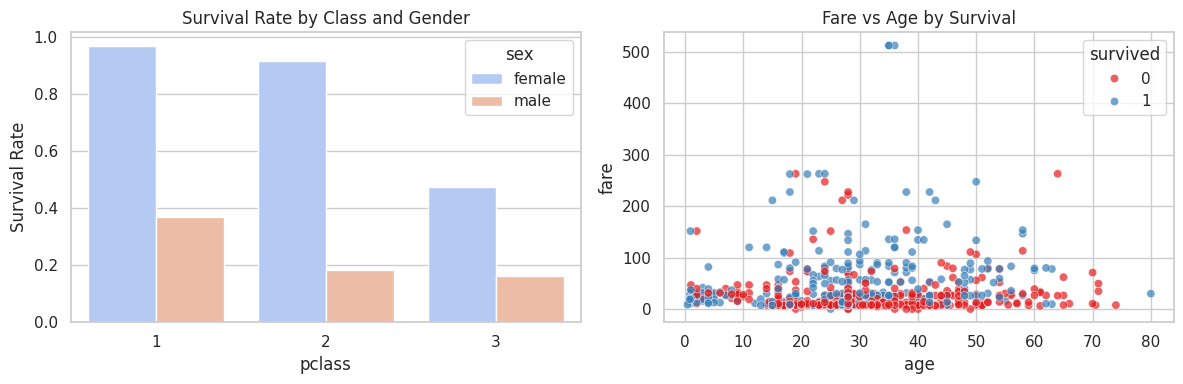

In [12]:
#Load dataset of titanic
titanic = sns.load_dataset('titanic')

# Cleaning
titanic.drop(columns=['deck', 'embark_town', 'alive'], inplace=True)
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic.drop_duplicates(inplace=True)

# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.barplot(data=titanic, x='pclass', y='survived', hue='sex', errorbar=None, palette='coolwarm')
plt.title('Survival Rate by Class and Gender')
plt.ylabel('Survival Rate')

plt.subplot(1, 2, 2)
sns.scatterplot(data=titanic, x='age', y='fare', hue='survived', alpha=0.7, palette='Set1')
plt.title('Fare vs Age by Survival')

plt.tight_layout()
plt.show()


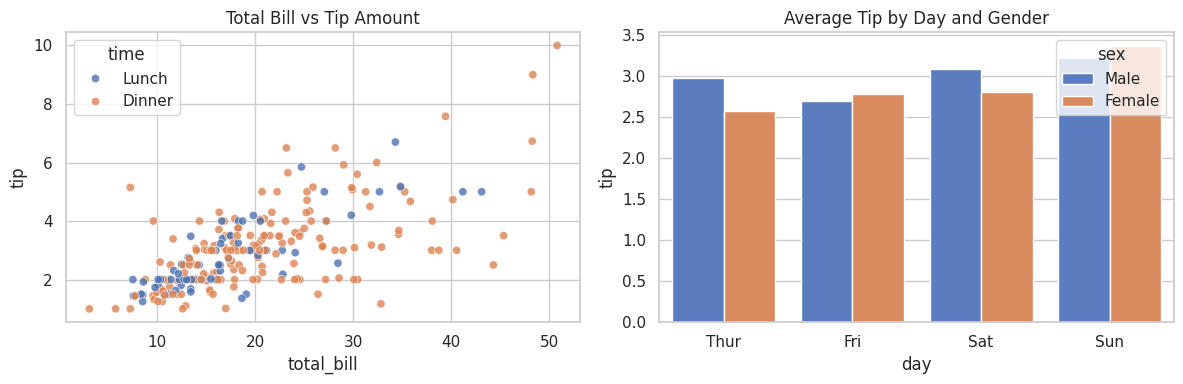

In [13]:
# Load dataset of tips
tips = sns.load_dataset('tips')

# Cleaning
tips.dropna(inplace=True)

# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', alpha=0.8)
plt.title('Total Bill vs Tip Amount')

plt.subplot(1, 2, 2)
sns.barplot(data=tips, x='day', y='tip', hue='sex', errorbar=None, palette='muted')
plt.title('Average Tip by Day and Gender')

plt.tight_layout()
plt.show()


/tmp/ipykernel_644/2217035024.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x='species', y='petal_length', palette='Set2')


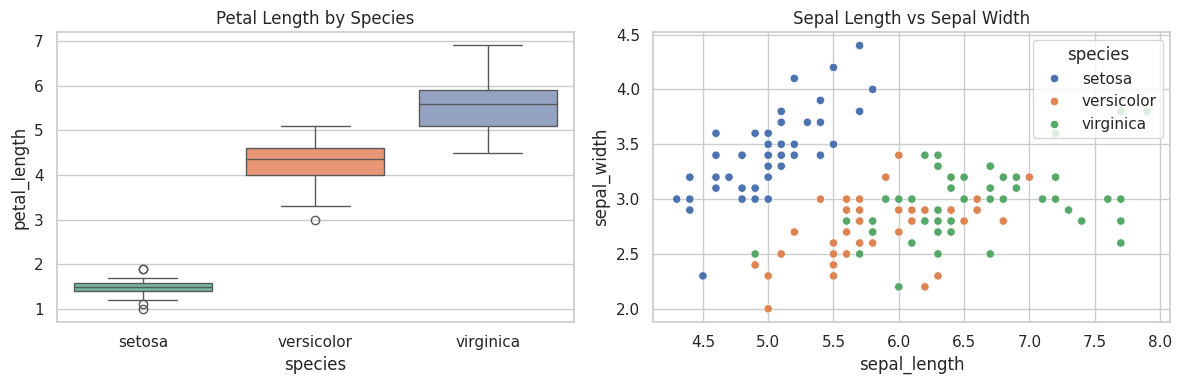

In [14]:
# Load dataset of Iris
iris = sns.load_dataset('iris')

# Cleaning
iris.drop_duplicates(inplace=True)

# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(data=iris, x='species', y='petal_length', palette='Set2')
plt.title('Petal Length by Species')

plt.subplot(1, 2, 2)
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species')
plt.title('Sepal Length vs Sepal Width')

plt.tight_layout()
plt.show()


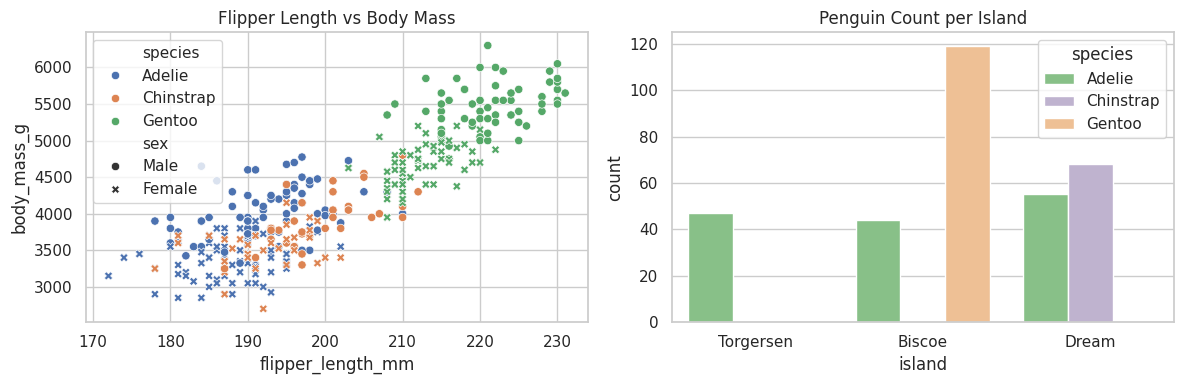

In [15]:
# Load dataset of penguins
penguins = sns.load_dataset('penguins')

# Cleaning: remove rows with missing measurement values
penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex'], inplace=True)

# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', hue='species', style='sex')
plt.title('Flipper Length vs Body Mass')

plt.subplot(1, 2, 2)
sns.countplot(data=penguins, x='island', hue='species', palette='Accent')
plt.title('Penguin Count per Island')

plt.tight_layout()
plt.show()


/tmp/ipykernel_644/2670942381.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diamonds, x='cut', y='price', errorbar=None, palette='Blues_d')


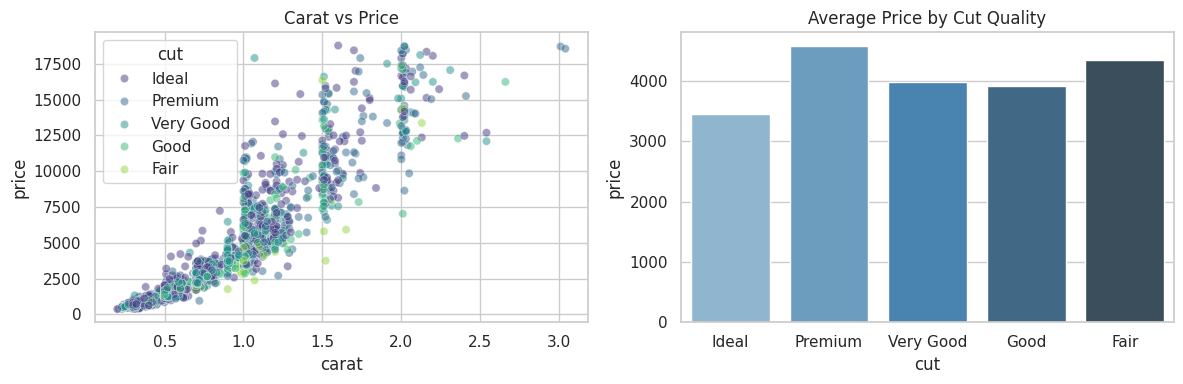

In [16]:
# Load dataset of diamonds
diamonds = sns.load_dataset('diamonds')

# Cleaning: remove impossible zero values in dimensions (x, y, z)
diamonds = diamonds[(diamonds['x'] > 0) & (diamonds['y'] > 0) & (diamonds['z'] > 0)]

# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
# Taking a random sample to keep scatter readable
sample_diamonds = diamonds.sample(n=2000, random_state=42)
sns.scatterplot(data=sample_diamonds, x='carat', y='price', hue='cut', alpha=0.5, palette='viridis')
plt.title('Carat vs Price')

plt.subplot(1, 2, 2)
sns.barplot(data=diamonds, x='cut', y='price', errorbar=None, palette='Blues_d')
plt.title('Average Price by Cut Quality')

plt.tight_layout()
plt.show()


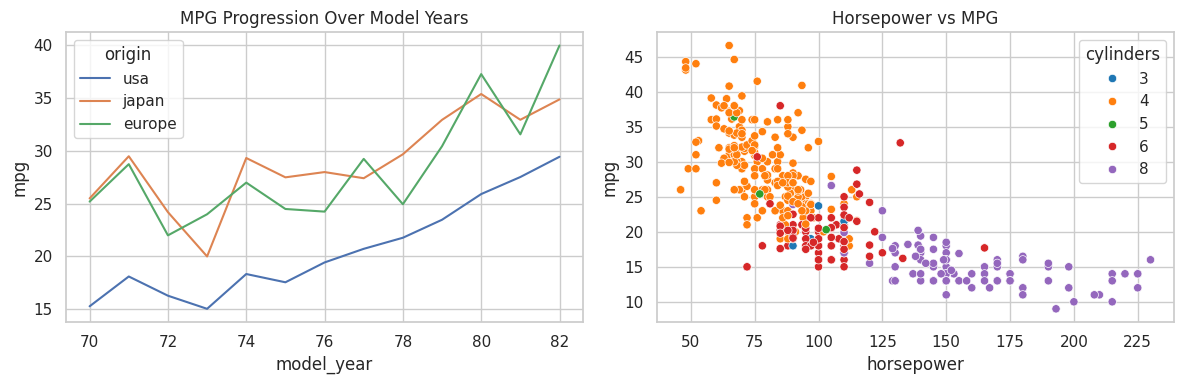

In [17]:
# Load dataset of Auto mpg
mpg = sns.load_dataset('mpg')

# Cleaning: fill missing horsepower values with column median
mpg['horsepower'] = mpg['horsepower'].fillna(mpg['horsepower'].median())

# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.lineplot(data=mpg, x='model_year', y='mpg', hue='origin', errorbar=None)
plt.title('MPG Progression Over Model Years')

plt.subplot(1, 2, 2)
sns.scatterplot(data=mpg, x='horsepower', y='mpg', hue='cylinders', palette='tab10')
plt.title('Horsepower vs MPG')

plt.tight_layout()
plt.show()

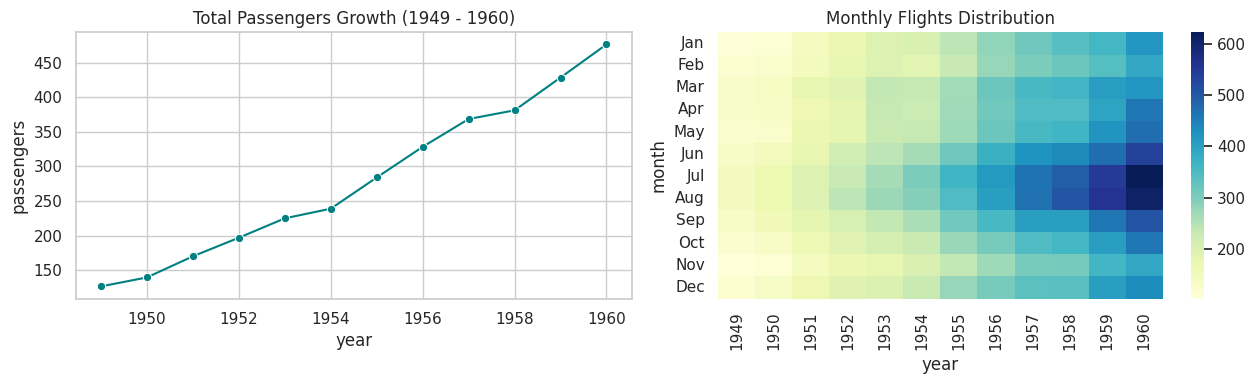

In [18]:
# Load dataset of flight
flights = sns.load_dataset('flights')

# Cleaning: verify data types and pivot for heatmap matrix
flights_matrix = flights.pivot(index='month', columns='year', values='passengers')

# Visualizations
plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
sns.lineplot(data=flights, x='year', y='passengers', errorbar=None, marker='o', color='teal')
plt.title('Total Passengers Growth (1949 - 1960)')

plt.subplot(1, 2, 2)
sns.heatmap(flights_matrix, cmap='YlGnBu')
plt.title('Monthly Flights Distribution')

plt.tight_layout()
plt.show()

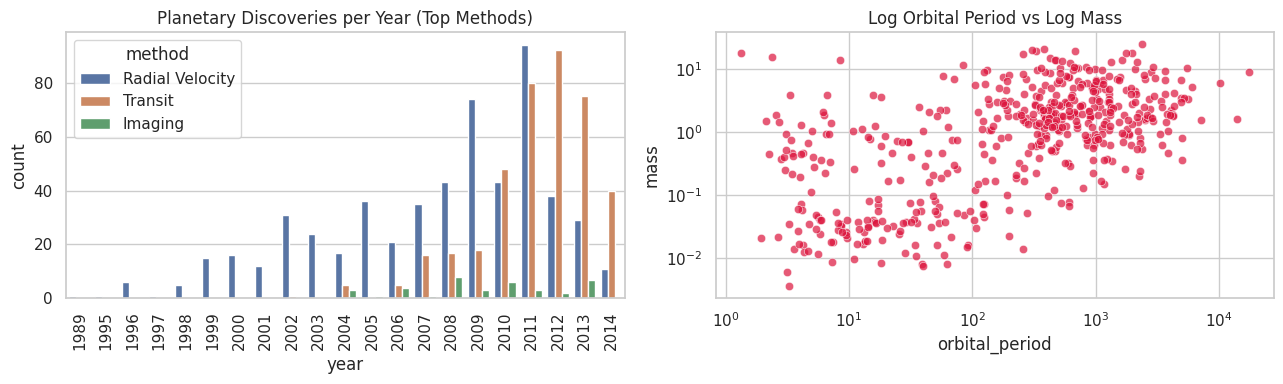

In [19]:
# Load dataset of planets
planets = sns.load_dataset('planets')

# Cleaning: filter valid records for discovery year and mass
clean_planets = planets.dropna(subset=['year', 'mass', 'orbital_period']).copy()

# Visualizations
plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
top_methods = planets['method'].value_counts().head(3).index
sns.countplot(data=planets[planets['method'].isin(top_methods)], x='year', hue='method')
plt.xticks(rotation=90)
plt.title('Planetary Discoveries per Year (Top Methods)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=clean_planets, x='orbital_period', y='mass', alpha=0.7, color='crimson')
plt.xscale('log')
plt.yscale('log')
plt.title('Log Orbital Period vs Log Mass')

plt.tight_layout()
plt.show()

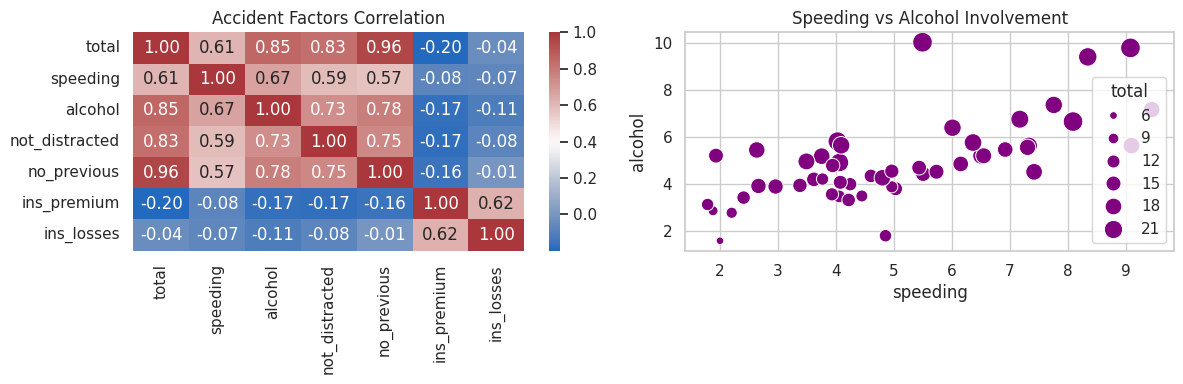

In [20]:
# Load dataset of crashes
crashes = sns.load_dataset('car_crashes')

# Cleaning: isolate numeric metrics for correlation
crashes_num = crashes.drop(columns=['abbrev'])

# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(crashes_num.corr(), annot=True, cmap='vlag', fmt='.2f')
plt.title('Accident Factors Correlation')

plt.subplot(1, 2, 2)
sns.scatterplot(data=crashes, x='speeding', y='alcohol', size='total', sizes=(30, 200), color='purple')
plt.title('Speeding vs Alcohol Involvement')

plt.tight_layout()
plt.show()

/tmp/ipykernel_644/2472729400.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=taxis, x='payment', y='tip', errorbar=None, palette='pastel')


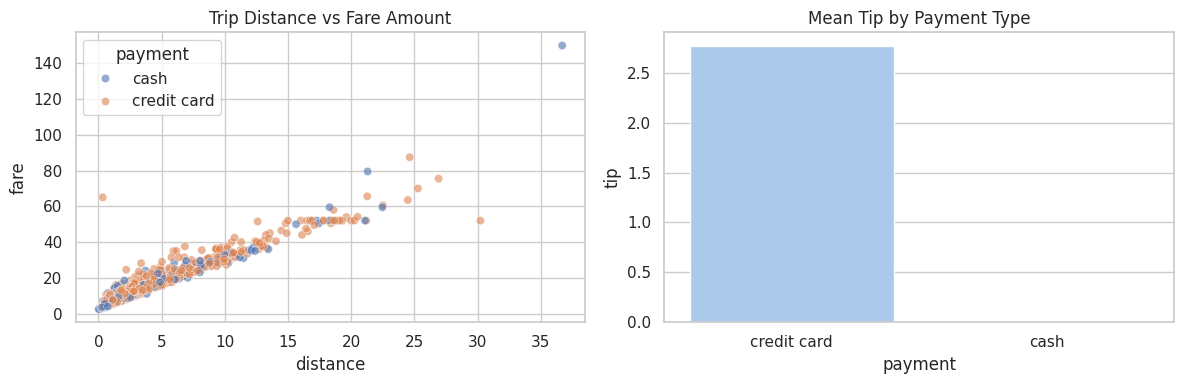

In [21]:
# Load dataset of taxis
taxis = sns.load_dataset('taxis')

# Cleaning: remove zero/negative distance & fares, remove null payment rows
taxis = taxis[(taxis['distance'] > 0) & (taxis['fare'] > 0)].copy()
taxis.dropna(subset=['payment'], inplace=True)

# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(data=taxis.sample(1500, random_state=42), x='distance', y='fare', hue='payment', alpha=0.6)
plt.title('Trip Distance vs Fare Amount')

plt.subplot(1, 2, 2)
sns.barplot(data=taxis, x='payment', y='tip', errorbar=None, palette='pastel')
plt.title('Mean Tip by Payment Type')

plt.tight_layout()
plt.show()
